# Task 3 — Energy Consumption Time Series Forecasting

**Dataset:** Household Power Consumption (UCI)  
**Goal:** Forecast energy usage using ARIMA, Prophet, and XGBoost.

---
**Topics:** Time Series · Feature Engineering · ARIMA · Prophet · XGBoost · MAE · RMSE


## Step 0 · Install Libraries

In [1]:
import subprocess, sys

packages = ["pandas", "numpy", "matplotlib", "seaborn",
            "scikit-learn", "statsmodels", "prophet", "xgboost"]

for pkg in packages:
    print(f"Installing {pkg}...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("\nAll packages installed!")


Installing pandas...
Installing numpy...
Installing matplotlib...
Installing seaborn...
Installing scikit-learn...
Installing statsmodels...
Installing prophet...
Installing xgboost...

All packages installed!


## Step 1 · Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from prophet import Prophet
from xgboost import XGBRegressor

print("Imports done!")


Importing plotly failed. Interactive plots will not work.


Imports done!



## Step 2 · Load Dataset



In [3]:
# Load the raw CSV
# The file uses semicolons as separator and ? for missing values
df = pd.read_csv(
    "household_power_consumption.txt",
    sep=";",
    na_values=["?"],
    low_memory=False
)

print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()


Shape: (2075259, 9)
Columns: ['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0



## Step 3 · Create Datetime Index

In [4]:
# Combine the Date and Time columns into one datetime column
df["datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    dayfirst=True,
    format="mixed"
)

# Set datetime as the index and drop the old columns
df = df.drop(columns=["Date", "Time"])
df = df.set_index("datetime")

# Convert everything to numbers
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Shape:", df.shape)
print("Date range:", df.index.min(), "to", df.index.max())
print("Missing values:", df.isnull().sum().sum())
df.head()


Shape: (2075259, 7)
Date range: 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Missing values: 181853


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0



## Step 4 · Resample to Hourly (from 1-minute)

In [5]:
# We only need Global_active_power (energy in kilowatts)
target = "Global_active_power"

# Resample: average each hour into one row (reduces ~2M rows to ~35K)
df_hourly = df[[target]].resample("h").mean()

# Fill any missing hours using forward fill
df_hourly = df_hourly.ffill()

print("Hourly shape:", df_hourly.shape)
print("Missing values after fill:", df_hourly.isnull().sum().values[0])
df_hourly.head()


Hourly shape: (34589, 1)
Missing values after fill: 0


,Global_active_power
datetime,
2006-12-16 17:00:00,4.222889
2006-12-16 18:00:00,3.632200
2006-12-16 19:00:00,3.400233
2006-12-16 20:00:00,3.268567
2006-12-16 21:00:00,3.056467



## Step 5 · Exploratory Data Analysis (EDA)

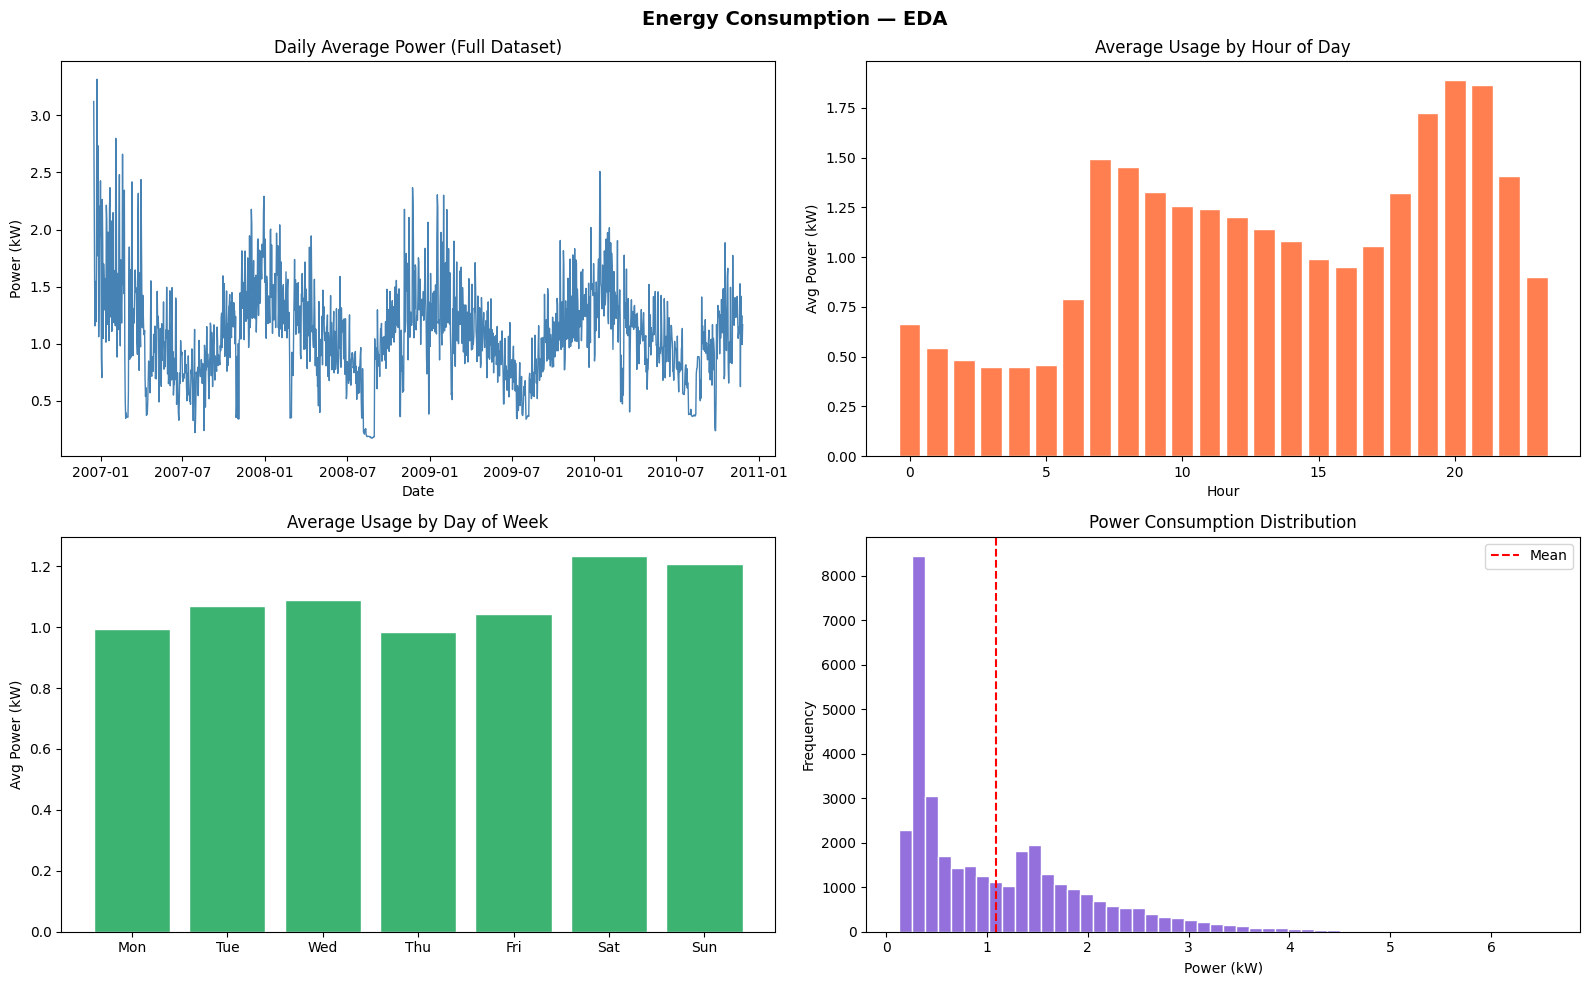

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Energy Consumption — EDA", fontsize=14, fontweight="bold")

# 1. Overall trend (daily average)
daily = df_hourly[target].resample("D").mean()
axes[0,0].plot(daily.index, daily.values, color="steelblue", lw=1)
axes[0,0].set_title("Daily Average Power (Full Dataset)")
axes[0,0].set_ylabel("Power (kW)")
axes[0,0].set_xlabel("Date")

# 2. Average by hour of day
df_hourly["hour"] = df_hourly.index.hour
hourly_avg = df_hourly.groupby("hour")[target].mean()
axes[0,1].bar(hourly_avg.index, hourly_avg.values, color="coral", edgecolor="white")
axes[0,1].set_title("Average Usage by Hour of Day")
axes[0,1].set_ylabel("Avg Power (kW)")
axes[0,1].set_xlabel("Hour")

# 3. Average by day of week
df_hourly["dayofweek"] = df_hourly.index.dayofweek
day_avg = df_hourly.groupby("dayofweek")[target].mean()
axes[1,0].bar(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"],
              day_avg.values, color="mediumseagreen", edgecolor="white")
axes[1,0].set_title("Average Usage by Day of Week")
axes[1,0].set_ylabel("Avg Power (kW)")

# 4. Distribution
axes[1,1].hist(df_hourly[target].dropna(), bins=50, color="mediumpurple", edgecolor="white")
axes[1,1].axvline(df_hourly[target].mean(), color="red", linestyle="--", label="Mean")
axes[1,1].set_title("Power Consumption Distribution")
axes[1,1].set_xlabel("Power (kW)")
axes[1,1].set_ylabel("Frequency")
axes[1,1].legend()

# Clean up helper columns
df_hourly = df_hourly.drop(columns=["hour","dayofweek"])

plt.tight_layout()
plt.savefig("eda.png", dpi=130, bbox_inches="tight")
plt.show()



## Step 6 · Stationarity Test + ACF / PACF

ADF Statistic : -7.4445
p-value       : 0.0
Result: Series is STATIONARY (good for ARIMA)


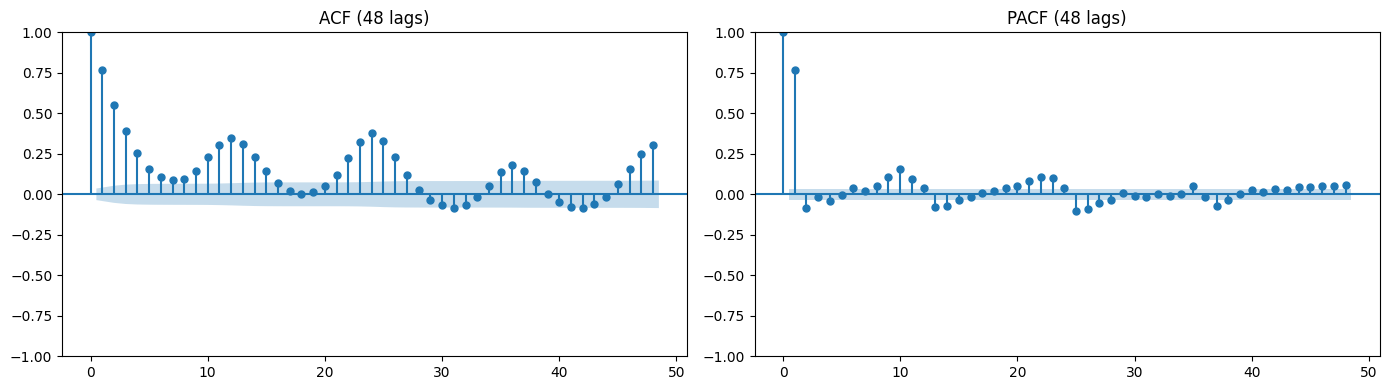

In [7]:
# Augmented Dickey-Fuller test (checks if series is stationary)
sample = df_hourly[target].dropna().iloc[:3000]
result = adfuller(sample)

print("ADF Statistic :", round(result[0], 4))
print("p-value       :", round(result[1], 6))
if result[1] < 0.05:
    print("Result: Series is STATIONARY (good for ARIMA)")
else:
    print("Result: Series is NON-STATIONARY (may need differencing)")

# ACF and PACF plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(sample,  lags=48, ax=axes[0], title="ACF (48 lags)")
plot_pacf(sample, lags=48, ax=axes[1], title="PACF (48 lags)", method="ywm")
plt.tight_layout()
plt.savefig("acf_pacf.png", dpi=130, bbox_inches="tight")
plt.show()



## Step 7 · Feature Engineering (for XGBoost)

In [8]:
df_feat = df_hourly.copy()

# Time-based features
df_feat["hour"]       = df_feat.index.hour
df_feat["dayofweek"]  = df_feat.index.dayofweek
df_feat["month"]      = df_feat.index.month
df_feat["is_weekend"] = (df_feat.index.dayofweek >= 5).astype(int)

# Lag features (past values as input)
df_feat["lag_1"]   = df_feat[target].shift(1)
df_feat["lag_24"]  = df_feat[target].shift(24)
df_feat["lag_168"] = df_feat[target].shift(168)

# Rolling average features
df_feat["rolling_mean_24"]  = df_feat[target].shift(1).rolling(24).mean()
df_feat["rolling_mean_168"] = df_feat[target].shift(1).rolling(168).mean()

# Drop rows with NaN (created by shifts)
df_feat = df_feat.dropna()

feature_cols = [c for c in df_feat.columns if c != target]
print("Features created:", feature_cols)
print("Dataset shape   :", df_feat.shape)


Features created: ['hour', 'dayofweek', 'month', 'is_weekend', 'lag_1', 'lag_24', 'lag_168', 'rolling_mean_24', 'rolling_mean_168']
Dataset shape   : (34421, 10)



## Step 8 · Train / Test Split (last 7 days = test)

Train: 2006-12-23 17:00:00 to 2010-11-19 21:00:00 (34253 rows)
Test : 2010-11-19 22:00:00 to 2010-11-26 21:00:00 (168 rows)


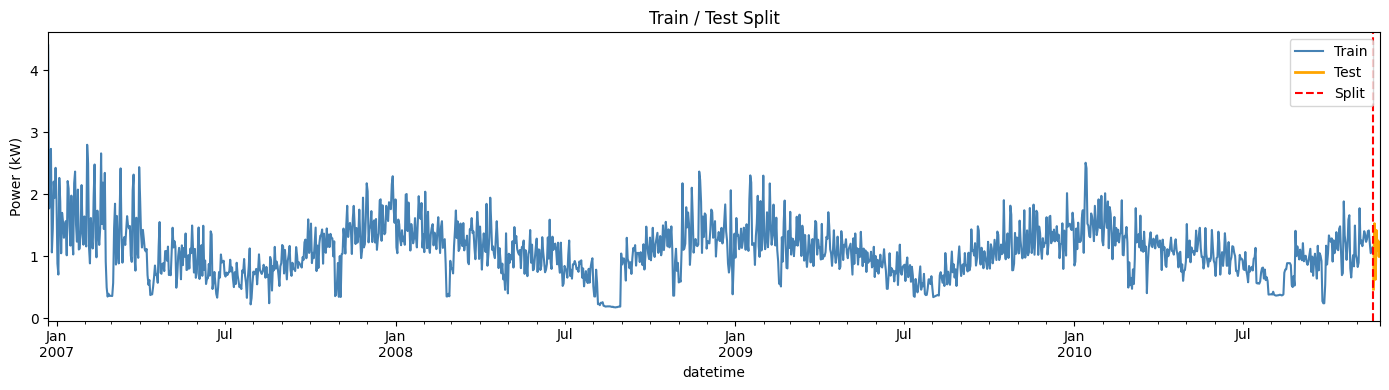

In [9]:
TEST_HOURS = 168   # 7 days

train = df_feat.iloc[:-TEST_HOURS]
test  = df_feat.iloc[-TEST_HOURS:]

y_train = train[target]
y_test  = test[target]
X_train = train[feature_cols]
X_test  = test[feature_cols]

print("Train:", train.index[0], "to", train.index[-1], f"({len(train)} rows)")
print("Test :", test.index[0],  "to", test.index[-1],  f"({len(test)} rows)")

# Plot the split
fig, ax = plt.subplots(figsize=(14, 4))
y_train.resample("D").mean().plot(ax=ax, label="Train", color="steelblue")
y_test.resample("D").mean().plot(ax=ax,  label="Test",  color="orange", linewidth=2)
ax.axvline(test.index[0], color="red", linestyle="--", label="Split")
ax.set_title("Train / Test Split")
ax.set_ylabel("Power (kW)")
ax.legend()
plt.tight_layout()
plt.savefig("train_test_split.png", dpi=130, bbox_inches="tight")
plt.show()



## Step 9 · Model 1 — ARIMA

In [10]:
# Use last 30 days of training data only (ARIMA is slow on large data)
arima_train = y_train.iloc[-24*30:]

print("Fitting ARIMA(2,1,2)...")
arima_model = ARIMA(arima_train, order=(2, 1, 2))
arima_fit   = arima_model.fit()

# Forecast 168 hours ahead
arima_pred = pd.Series(
    arima_fit.forecast(steps=TEST_HOURS).values,
    index=y_test.index
).clip(lower=0)

arima_mae  = mean_absolute_error(y_test, arima_pred)
arima_rmse = np.sqrt(mean_squared_error(y_test, arima_pred))

print(f"ARIMA  MAE  = {arima_mae:.4f} kW")
print(f"ARIMA  RMSE = {arima_rmse:.4f} kW")


Fitting ARIMA(2,1,2)...
ARIMA  MAE  = 0.6942 kW
ARIMA  RMSE = 0.8560 kW



## Step 10 · Model 2 — Prophet

In [11]:
# Prophet needs columns named 'ds' and 'y'
prophet_train = pd.DataFrame({
    "ds": y_train.index,
    "y":  y_train.values
})

print("Fitting Prophet...")
prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False,
    uncertainty_samples=0
)
prophet_model.fit(prophet_train)

# Predict on test dates
future        = pd.DataFrame({"ds": y_test.index})
prophet_fc    = prophet_model.predict(future)
prophet_pred  = pd.Series(
    prophet_fc["yhat"].values,
    index=y_test.index
).clip(lower=0)

prophet_mae  = mean_absolute_error(y_test, prophet_pred)
prophet_rmse = np.sqrt(mean_squared_error(y_test, prophet_pred))

print(f"Prophet  MAE  = {prophet_mae:.4f} kW")
print(f"Prophet  RMSE = {prophet_rmse:.4f} kW")


Fitting Prophet...


13:21:45 - cmdstanpy - INFO - Chain [1] start processing
13:22:03 - cmdstanpy - INFO - Chain [1] done processing


Prophet  MAE  = 0.5233 kW
Prophet  RMSE = 0.7687 kW



## Step 11 · Model 3 — XGBoost

In [12]:
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Fitting XGBoost...")
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train_sc, y_train)

xgb_pred = pd.Series(
    xgb_model.predict(X_test_sc),
    index=y_test.index
).clip(lower=0)

xgb_mae  = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

print(f"XGBoost  MAE  = {xgb_mae:.4f} kW")
print(f"XGBoost  RMSE = {xgb_rmse:.4f} kW")


Fitting XGBoost...
XGBoost  MAE  = 0.3572 kW
XGBoost  RMSE = 0.5513 kW



## Step 12 · Actual vs Forecasted — All Models

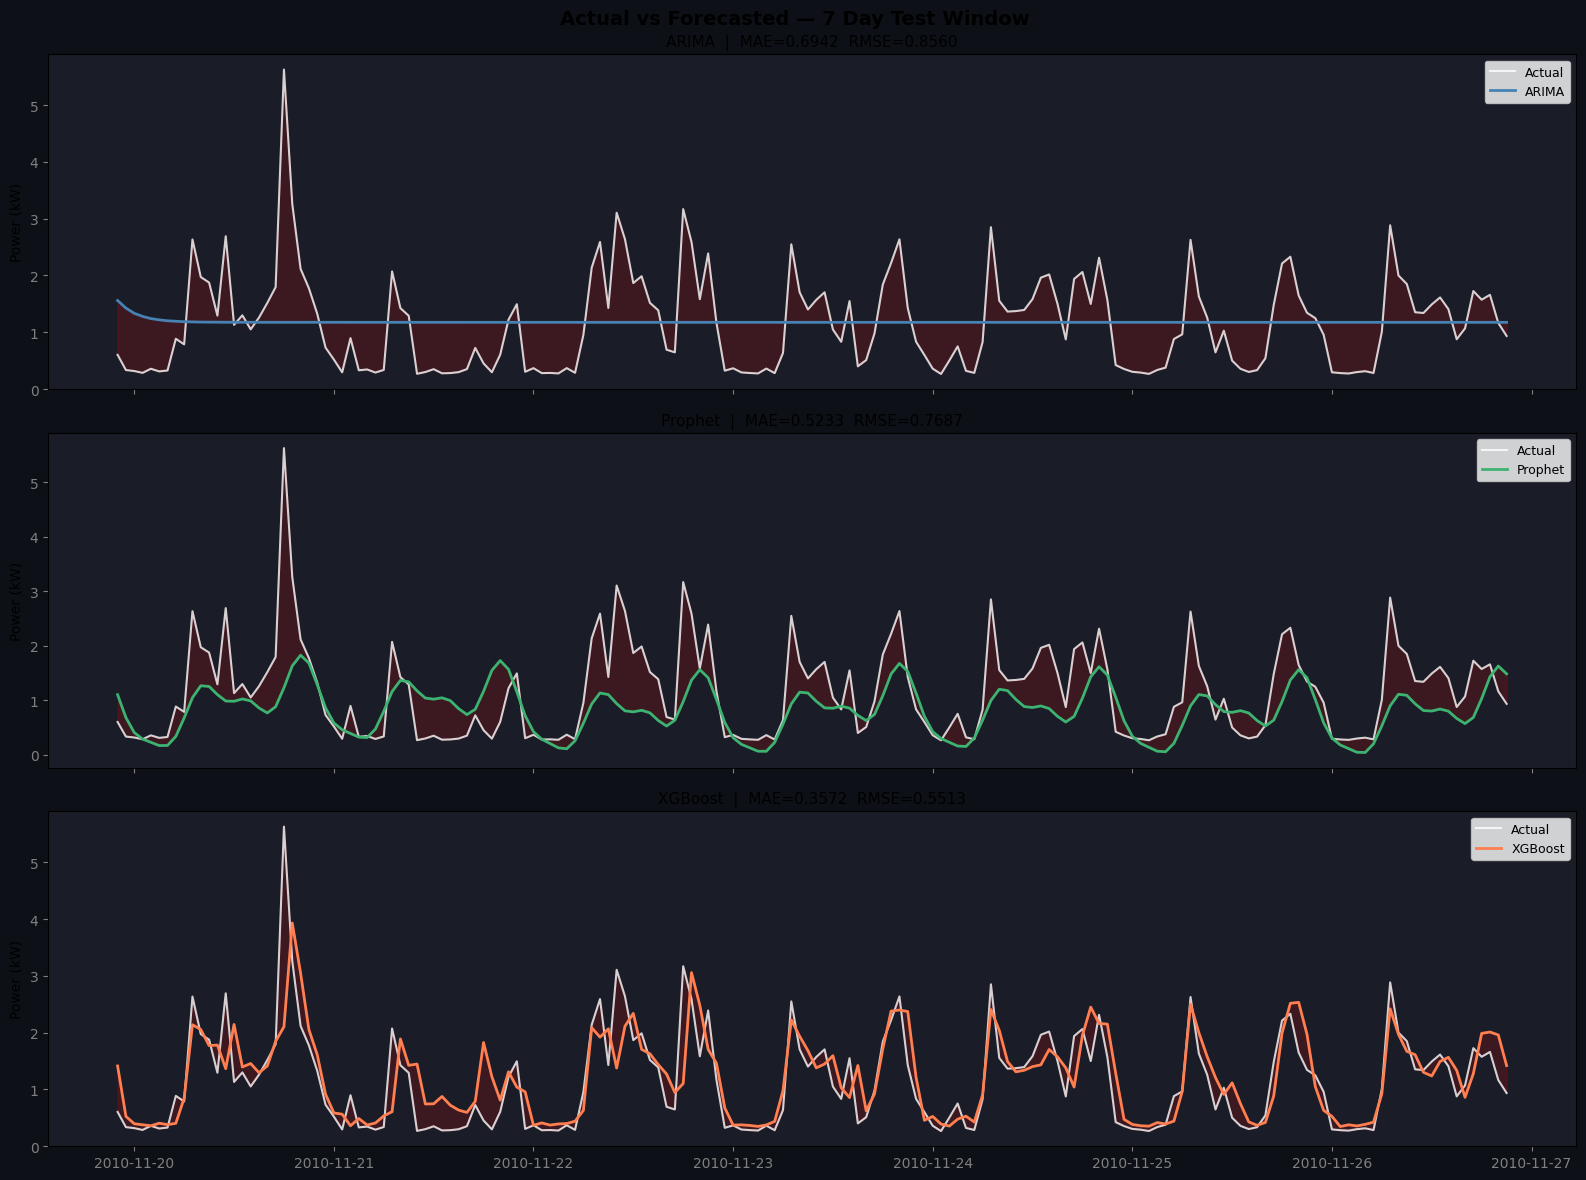

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
fig.suptitle("Actual vs Forecasted — 7 Day Test Window", fontsize=14, fontweight="bold")

models = [
    ("ARIMA",   arima_pred,   arima_mae,   arima_rmse,   "steelblue"),
    ("Prophet", prophet_pred, prophet_mae, prophet_rmse, "mediumseagreen"),
    ("XGBoost", xgb_pred,     xgb_mae,     xgb_rmse,    "coral"),
]

for ax, (name, pred, mae, rmse, color) in zip(axes, models):
    ax.plot(y_test.index, y_test.values,  color="white",  lw=1.5, alpha=0.8, label="Actual")
    ax.plot(pred.index,   pred.values,    color=color,    lw=2,              label=f"{name}")
    ax.fill_between(pred.index, y_test.values, pred.values, alpha=0.15, color="red")
    ax.set_title(f"{name}  |  MAE={mae:.4f}  RMSE={rmse:.4f}", fontsize=11)
    ax.set_ylabel("Power (kW)")
    ax.legend(fontsize=9)
    ax.set_facecolor("#1a1d27")

fig.patch.set_facecolor("#0d1117")
for ax in axes:
    ax.tick_params(colors="gray")
    ax.xaxis.label.set_color("gray")

plt.tight_layout()
plt.savefig("forecast_comparison.png", dpi=130, bbox_inches="tight", facecolor="#0d1117")
plt.show()



## Step 13 · XGBoost Feature Importance

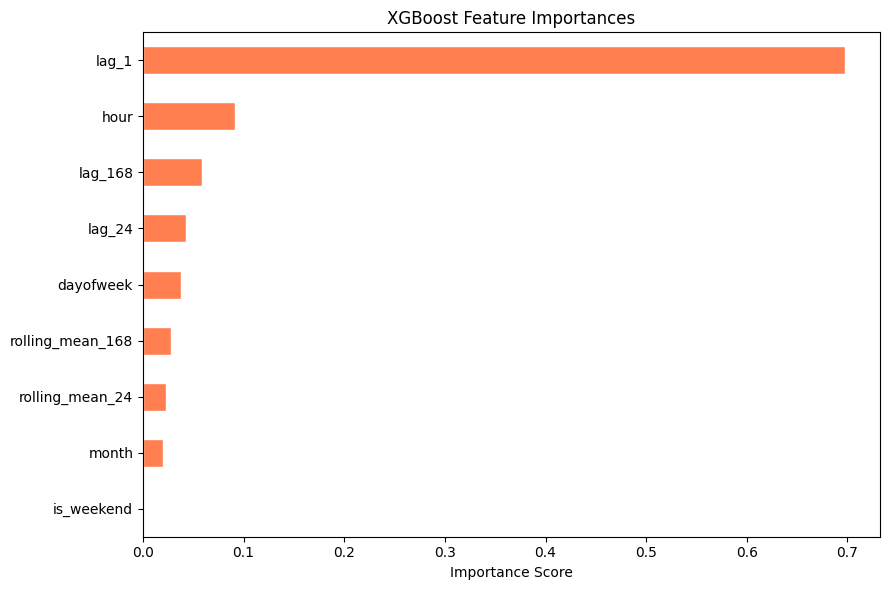

In [14]:
fi = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
fi.plot(kind="barh", ax=ax, color="coral", edgecolor="white")
ax.set_title("XGBoost Feature Importances")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=130, bbox_inches="tight")
plt.show()



## Step 14 · Final Results Summary

            MAE    RMSE
Model                  
ARIMA    0.6942  0.8560
Prophet  0.5233  0.7687
XGBoost  0.3572  0.5513

Best MAE  → XGBoost
Best RMSE → XGBoost


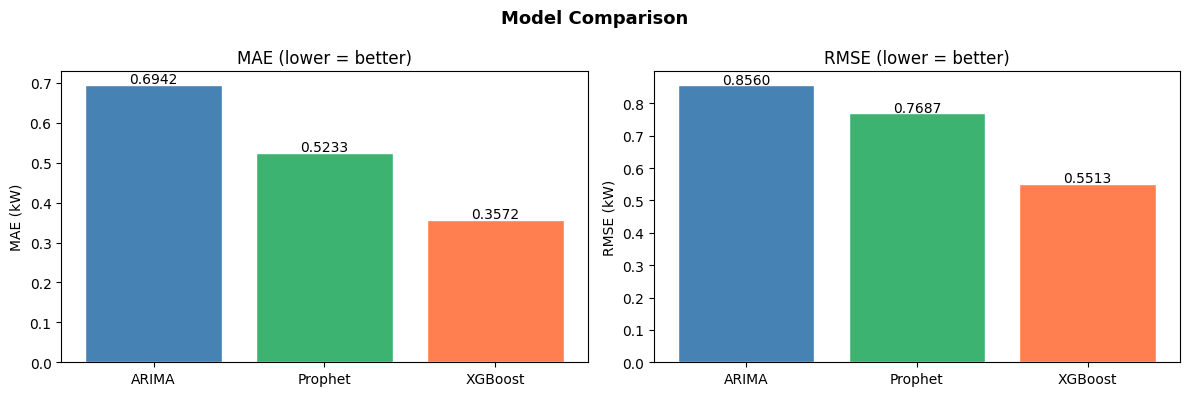


Pipeline complete!


In [15]:
results = pd.DataFrame({
    "Model": ["ARIMA", "Prophet", "XGBoost"],
    "MAE":   [arima_mae,   prophet_mae,   xgb_mae],
    "RMSE":  [arima_rmse,  prophet_rmse,  xgb_rmse],
}).set_index("Model").round(4)

print(results.to_string())
print(f"\nBest MAE  → {results['MAE'].idxmin()}")
print(f"Best RMSE → {results['RMSE'].idxmin()}")

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Model Comparison", fontsize=13, fontweight="bold")

colors = ["steelblue", "mediumseagreen", "coral"]
for ax, metric in zip(axes, ["MAE", "RMSE"]):
    bars = ax.bar(results.index, results[metric], color=colors, edgecolor="white")
    for bar, val in zip(bars, results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                val + 0.005, f"{val:.4f}", ha="center", fontsize=10)
    ax.set_title(f"{metric} (lower = better)")
    ax.set_ylabel(f"{metric} (kW)")

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

print("\nPipeline complete!")
